<a href="https://colab.research.google.com/github/MSIDIQ472/MUHAMMAD-SIDIQ_2411533011__ML2526/blob/main/Praktikum2/NaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set_style("darkgrid")

url = "https://raw.githubusercontent.com/MSIDIQ472/MUHAMMAD-SIDIQ_2411533011__ML2526/refs/heads/main/Praktikum2/Breast_cancer_data.csv"
df = pd.read_csv(url)
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


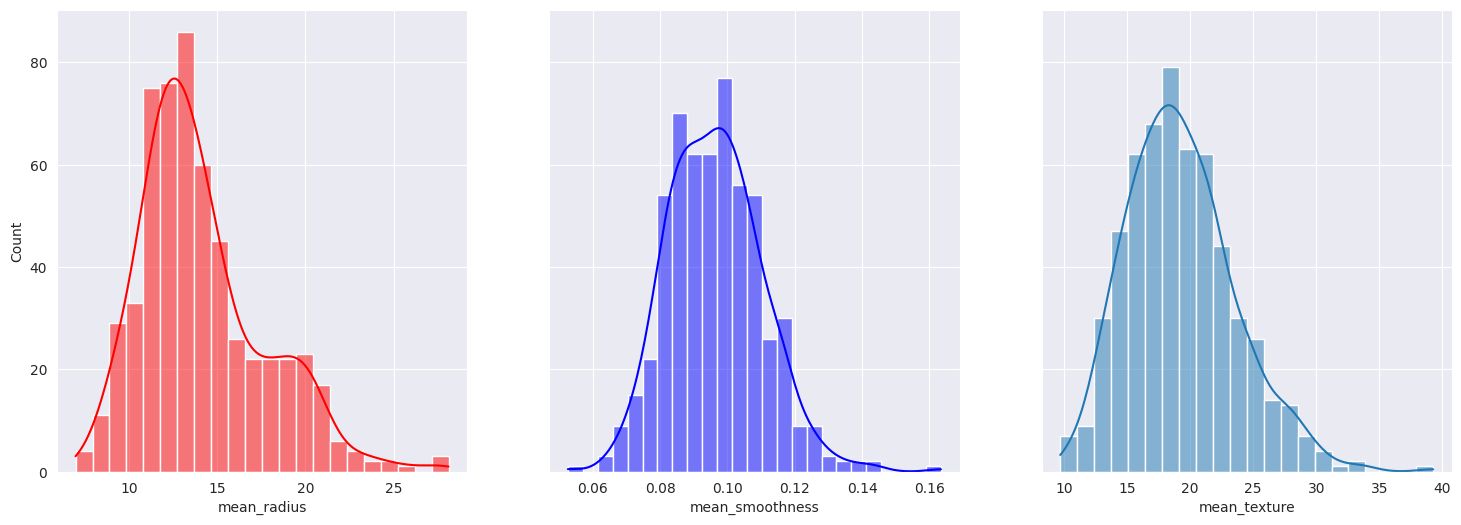

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
sns.histplot(df, ax=axes[0], x="mean_radius", kde=True, color='r')
sns.histplot(df, ax=axes[1], x="mean_smoothness", kde=True, color='b')
sns.histplot(df, ax=axes[2], x="mean_texture", kde=True)
plt.show()

In [3]:
def calculate_prior(df, Y):
    classes = sorted(list(df[Y].unique()))
    prior = []
    for i in classes:
        prior.append(len(df[df[Y]==i])/len(df))
    return prior

def calculate_likelihood_gaussian(df, feat_name, feat_val, Y, label):
    feat = list(df.columns)
    df = df[df[Y]==label]
    mean, std = df[feat_name].mean(), df[feat_name].std()
    p_x_given_y = (1 / (np.sqrt(2 * np.pi) * std)) * np.exp(-((feat_val-mean)**2 / (2 * std**2)))
    return p_x_given_y

def naive_bayes_gaussian(df, X, Y):
    features = list(df.columns)[:-1]
    prior = calculate_prior(df, Y)
    Y_pred = []
    for x in X:
        labels = sorted(list(df[Y].unique()))
        likelihood = [1]*len(labels)
        for j in range(len(labels)):
            for i in range(len(features)):
                likelihood[j] *= calculate_likelihood_gaussian(df, features[i], x[i], Y, labels[j])
        post_prob = [1]*len(labels)
        for j in range(len(labels)):
            post_prob[j] = likelihood[j] * prior[j]
        Y_pred.append(np.argmax(post_prob))
    return np.array(Y_pred)

In [4]:
train, test = train_test_split(df, test_size=.2, random_state=41)

X_test = test.iloc[:,:-1].values
y_test = test.iloc[:,-1].values
y_pred = naive_bayes_gaussian(train, X=X_test, Y="diagnosis")

print('Akurasi = ', accuracy_score(y_test, y_pred))
print('F1-Score = ', f1_score(y_test, y_pred))

Akurasi =  0.9473684210526315
F1-Score =  0.96


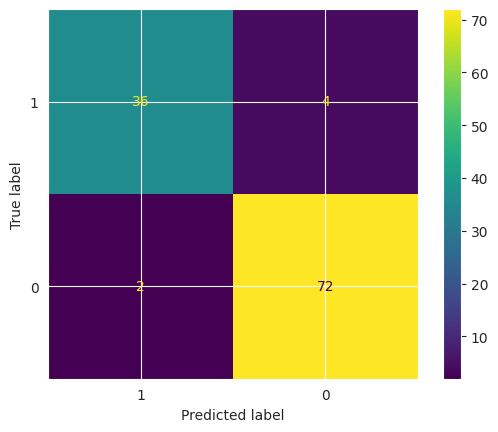

In [8]:
labels = [1, 0]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.show()

In [7]:
from sklearn.naive_bayes import GaussianNB

X_train = train.iloc[:,:-1].values
y_train = train.iloc[:,-1].values

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_sklearn = gnb.predict(X_test)

In [9]:
print("=== Sklearn GaussianNB ===")
print('Akurasi = ', accuracy_score(y_test, y_pred_sklearn))
print('F1-Score = ', f1_score(y_test, y_pred_sklearn))

print("\n=== Model Manual ===")
print('Akurasi = ', accuracy_score(y_test, y_pred))
print('F1-Score = ', f1_score(y_test, y_pred))

=== Sklearn GaussianNB ===
Akurasi =  0.9473684210526315
F1-Score =  0.96

=== Model Manual ===
Akurasi =  0.9473684210526315
F1-Score =  0.96


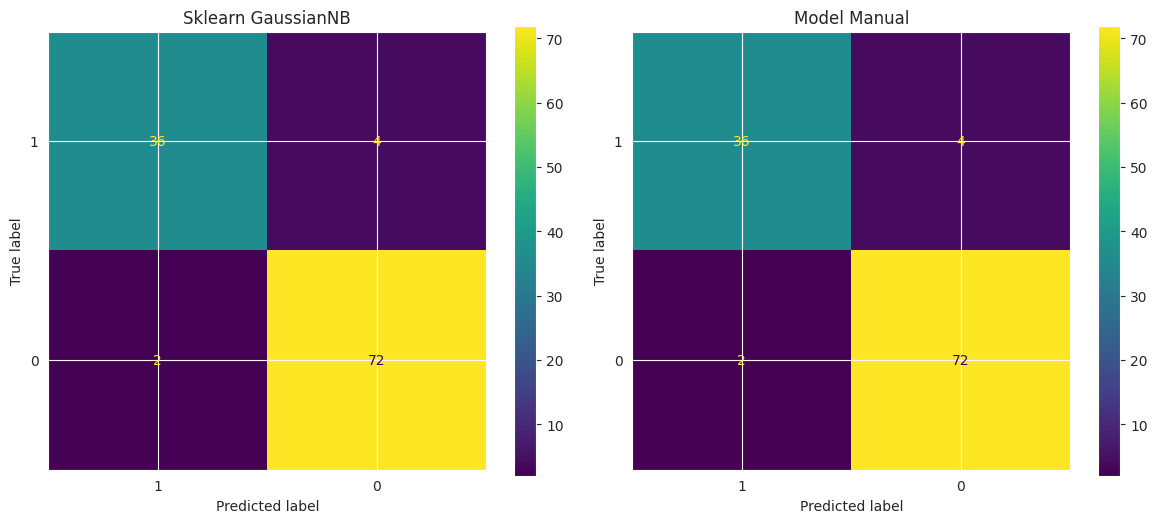

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
ConfusionMatrixDisplay(confusion_matrix=cm_sklearn, display_labels=[1, 0]).plot(ax=axes[0])
axes[0].set_title("Sklearn GaussianNB")

cm_manual = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_manual, display_labels=[1, 0]).plot(ax=axes[1])
axes[1].set_title("Model Manual")

plt.tight_layout()
plt.show()